In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

print('\n' + '='*100 )
print('Assignment: Comparative Study — Multi-Class Wine Quality Classification')
print('='*100 + '\n'*5)

print('='*50)
print('Task 1 — Load & Inspect the Data (Red + White)')
print('='*50 + '\n'*5)

red_wine = pd.read_csv('/content/winequality-red.csv', sep=';')
print('RED WINE DATASET')
print('='*50 + '\n')
print('Shape:', red_wine.shape)
print('\nFirst 5 rows:')
print(red_wine.head())
print('\nColumns:')
print(red_wine.columns.tolist())
print('\n'*5)

white_wine = pd.read_csv('/content/winequality-white.csv', sep=';')
print('WHITE WINE DATASET')
print('='*50 + '\n')
print('Shape:', white_wine.shape)
print('\nFirst 5 rows:')
print(white_wine.head())
print('\nColumns:')
print(white_wine.columns.tolist())



Assignment: Comparative Study — Multi-Class Wine Quality Classification





Task 1 — Load & Inspect the Data (Red + White)





RED WINE DATASET

Shape: (1599, 12)

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980 

Task 2 — Data Quality Checks + Class Distribution (Comparative)





RED WINE ANALYSIS

1. MISSING VALUES:
No missing values found

2. DUPLICATES:
Number of duplicate rows: 240

3. CLASS DISTRIBUTION:
         Count  Percentage
quality                   
3           10        0.63
4           53        3.31
5          681       42.59
6          638       39.90
7          199       12.45
8           18        1.13


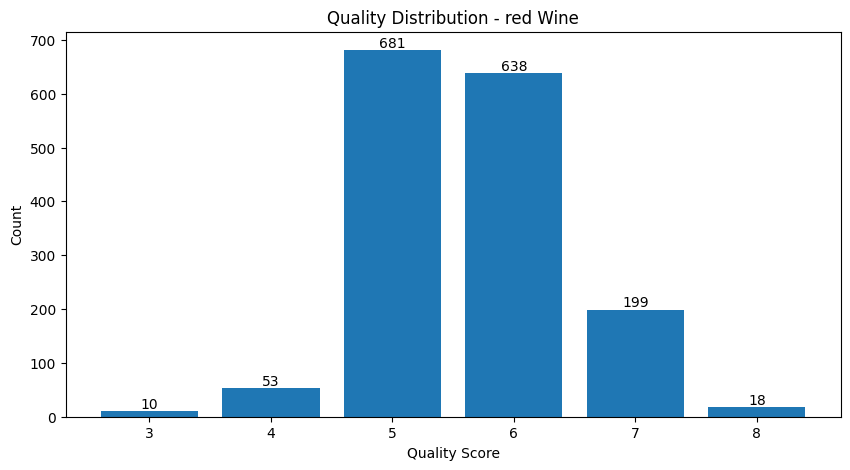







WHITE WINE ANALYSIS

1. MISSING VALUES:
No missing values found

2. DUPLICATES:
Number of duplicate rows: 937

3. CLASS DISTRIBUTION:
         Count  Percentage
quality                   
3           20        0.41
4          163        3.33
5         1457       29.75
6         2198       44.88
7          880       17.97
8          175        3.57
9            5        0.10


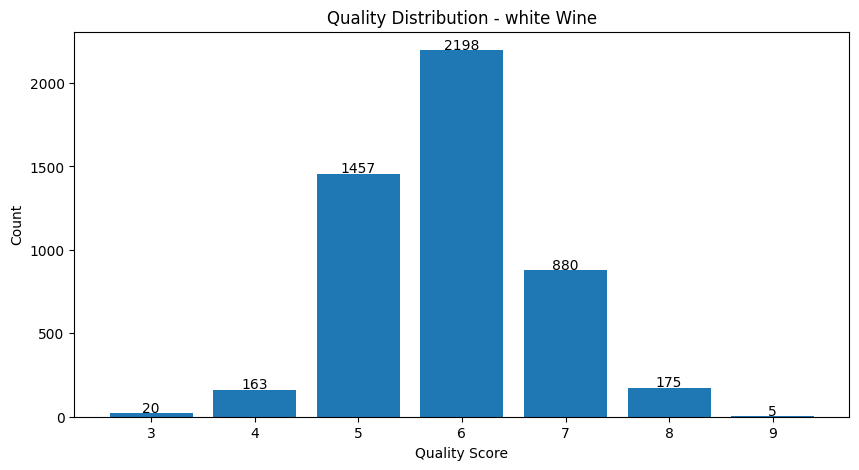

In [29]:
print('='*50)
print('Task 2 — Data Quality Checks + Class Distribution (Comparative)')
print('='*50 + '\n'*5)

def check_data_quality(df, wine_type):
    print(f"{wine_type.upper()} WINE ANALYSIS")
    print(f"{'='*50}")

    print("\n1. MISSING VALUES:")
    missing = df.isnull().sum()
    print(missing[missing > 0] if any(missing > 0) else "No missing values found")

    print("\n2. DUPLICATES:")
    duplicates = df.duplicated().sum()
    print(f"Number of duplicate rows: {duplicates}")

    print("\n3. CLASS DISTRIBUTION:")
    class_counts = df['quality'].value_counts().sort_index()
    class_percentages = (class_counts / len(df) * 100).round(2)

    distribution_df = pd.DataFrame({
        'Count': class_counts,
        'Percentage': class_percentages
    })
    print(distribution_df)

    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.index, class_counts.values)
    plt.title(f'Quality Distribution - {wine_type} Wine')
    plt.xlabel('Quality Score')
    plt.ylabel('Count')
    for i, v in enumerate(class_counts.values):
        plt.text(class_counts.index[i], v + 5, str(v), ha='center')
    plt.show()
    print('\n'*5)

    return duplicates, class_counts


red_duplicates, red_class_dist = check_data_quality(red_wine, 'red')
white_duplicates, white_class_dist = check_data_quality(white_wine, 'white')

In [27]:
print('='*50)
print('Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison) ')
print('='*50 + '\n'*5)

X_red = red_wine.drop('quality', axis=1)
y_red = red_wine['quality']

X_white = white_wine.drop('quality', axis=1)
y_white = white_wine['quality']


X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(X_red, y_red, test_size=0.2, random_state=42, stratify=y_red)
X_white_train, X_white_test, y_white_train, y_white_test = train_test_split(X_white, y_white, test_size=0.2, random_state=42, stratify=y_white)

print("RED WINE - Train set shape:", X_red_train.shape)
print("RED WINE - Test set shape:", X_red_test.shape)
print("\nWHITE WINE - Train set shape:", X_white_train.shape)
print("WHITE WINE - Test set shape:", X_white_test.shape)


print("\nVerifying stratification (Red Wine):\n")
print("Train set class distribution:")
print(y_red_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest set class distribution:")
print(y_red_test.value_counts(normalize=True).sort_index().round(3))

print("\nVerifying stratification (White Wine):\n")
print("Train set class distribution:")
print(y_white_train.value_counts(normalize=True).sort_index().round(3))
print("\nTest set class distribution:")
print(y_white_test.value_counts(normalize=True).sort_index().round(3))

Task 3 — Prepare Data for Modeling (Same Setup for Fair Comparison) 





RED WINE - Train set shape: (1279, 11)
RED WINE - Test set shape: (320, 11)

WHITE WINE - Train set shape: (3918, 11)
WHITE WINE - Test set shape: (980, 11)

Verifying stratification (Red Wine):

Train set class distribution:
quality
3    0.006
4    0.033
5    0.426
6    0.399
7    0.124
8    0.012
Name: proportion, dtype: float64

Test set class distribution:
quality
3    0.006
4    0.034
5    0.425
6    0.400
7    0.125
8    0.009
Name: proportion, dtype: float64

Verifying stratification (White Wine):

Train set class distribution:
quality
3    0.004
4    0.033
5    0.298
6    0.449
7    0.180
8    0.036
9    0.001
Name: proportion, dtype: float64

Test set class distribution:
quality
3    0.004
4    0.034
5    0.297
6    0.449
7    0.180
8    0.036
9    0.001
Name: proportion, dtype: float64


Task 4 — Model A (Baseline): Logistic Regression (Red vs White) 





LOGISTIC REGRESSION - RED WINE

Accuracy: 0.5844
Macro F1-Score: 0.2448

Confusion Matrix:
[[  0   0   1   1   0   0]
 [  0   0  10   1   0   0]
 [  0   0 104  31   1   0]
 [  0   0  50  78   0   0]
 [  0   0   2  33   5   0]
 [  0   0   0   2   1   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


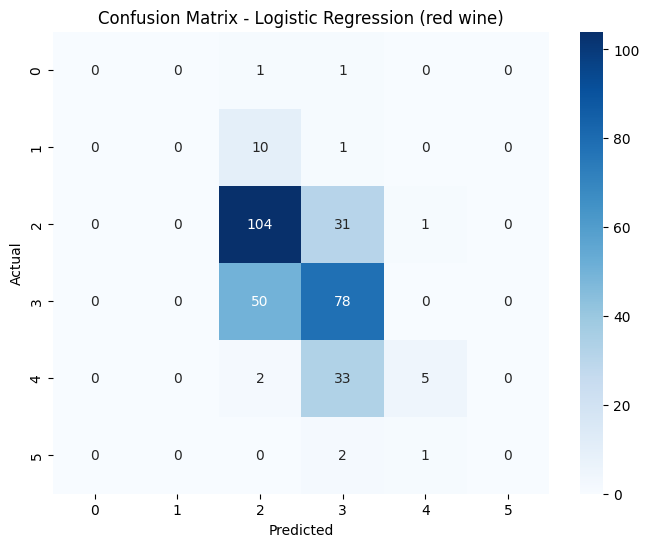


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.76      0.69       136
           6       0.53      0.61      0.57       128
           7       0.71      0.12      0.21        40
           8       0.00      0.00      0.00         3

    accuracy                           0.58       320
   macro avg       0.31      0.25      0.24       320
weighted avg       0.57      0.58      0.55       320







LOGISTIC REGRESSION - WHITE WINE


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l


Accuracy: 0.5276
Macro F1-Score: 0.1978

Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   0  21  12   0   0   0]
 [  0   0 147 144   0   0   0]
 [  0   0  77 344  19   0   0]
 [  0   0   6 144  26   0   0]
 [  0   0   0  25  10   0   0]
 [  0   0   0   0   1   0   0]]


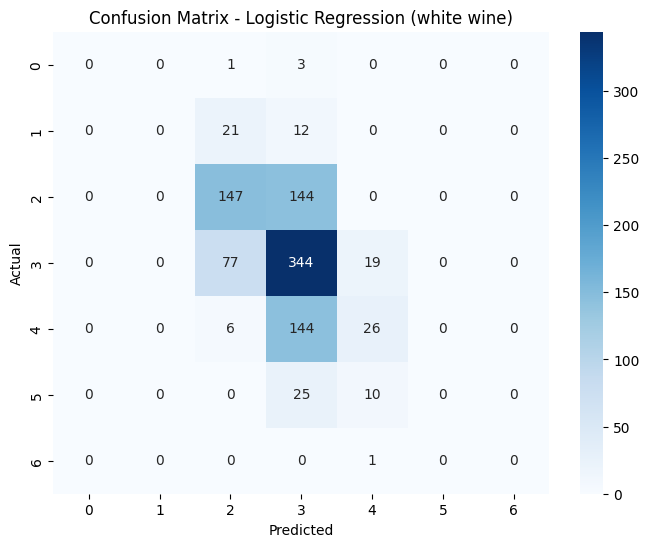


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        33
           5       0.58      0.51      0.54       291
           6       0.51      0.78      0.62       440
           7       0.46      0.15      0.22       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.53       980
   macro avg       0.22      0.20      0.20       980
weighted avg       0.49      0.53      0.48       980









/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [43]:
print('='*50)
print('Task 4 — Model A (Baseline): Logistic Regression (Red vs White) ')
print('='*50 + '\n'*5)

def logistic_regression_pipeline(X_train, X_test, y_train, y_test, wine_type):
    print(f"LOGISTIC REGRESSION - {wine_type.upper()} WINE")
    print(f"{'='*50}")

    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=5000, random_state=42, multi_class='ovr'))
    ])

    lr_pipeline.fit(X_train, y_train)

    y_pred = lr_pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Logistic Regression ({wine_type} wine)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print('\n'*5)
    return accuracy, f1, cm, y_pred, lr_pipeline


lr_red_acc, lr_red_f1, lr_red_cm, lr_red_pred, lr_pipeline_red = logistic_regression_pipeline(X_red_train, X_red_test, y_red_train, y_red_test, 'red')
lr_white_acc, lr_white_f1, lr_white_cm, lr_white_pred, lr_pipeline_white = logistic_regression_pipeline(X_white_train, X_white_test, y_white_train, y_white_test, 'white')

Task 5 — Model B (Tree Model): Random Forest (Red vs White)  





RANDOM FOREST - RED WINE

Accuracy: 0.6813
Macro F1-Score: 0.4094

Confusion Matrix:
[[  0   1   1   0   0   0]
 [  0   0   8   3   0   0]
 [  0   0 103  32   1   0]
 [  0   0  32  92   4   0]
 [  0   0   2  15  22   1]
 [  0   0   0   1   1   1]]


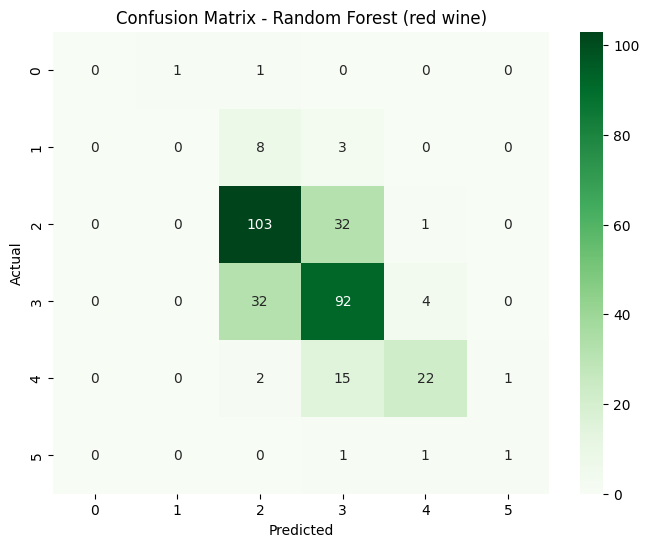


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.64      0.72      0.68       128
           7       0.79      0.55      0.65        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.44      0.39      0.41       320
weighted avg       0.66      0.68      0.67       320







RANDOM FOREST - WHITE WINE


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Accuracy: 0.6724
Macro F1-Score: 0.4222

Confusion Matrix:
[[  0   0   1   3   0   0   0]
 [  0   6  19   8   0   0   0]
 [  0   3 189  99   0   0   0]
 [  0   1  53 359  27   0   0]
 [  0   0   4  86  86   0   0]
 [  0   0   1   8   7  19   0]
 [  0   0   0   0   1   0   0]]


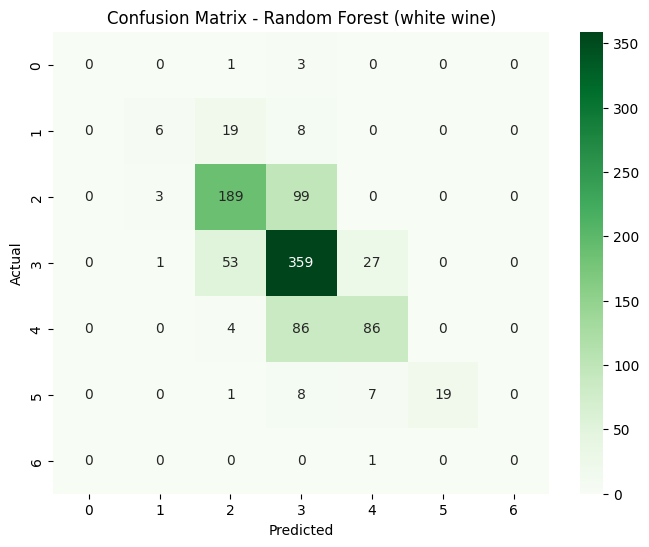


Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.60      0.18      0.28        33
           5       0.71      0.65      0.68       291
           6       0.64      0.82      0.72       440
           7       0.71      0.49      0.58       176
           8       1.00      0.54      0.70        35
           9       0.00      0.00      0.00         1

    accuracy                           0.67       980
   macro avg       0.52      0.38      0.42       980
weighted avg       0.68      0.67      0.66       980









/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [44]:
print('='*50)
print('Task 5 — Model B (Tree Model): Random Forest (Red vs White)  ')
print('='*50 + '\n'*5)

def random_forest_pipeline(X_train, X_test, y_train, y_test, wine_type):
    print(f"RANDOM FOREST - {wine_type.upper()} WINE")
    print(f"{'='*50}")

    rf_model = RandomForestClassifier(n_estimators=300, random_state=42)

    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix - Random Forest ({wine_type} wine)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print('\n'*5)

    return accuracy, f1, cm, y_pred, rf_model


rf_red_acc, rf_red_f1, rf_red_cm, rf_red_pred, rf_model_red = random_forest_pipeline( X_red_train, X_red_test, y_red_train, y_red_test, 'red')
rf_white_acc, rf_white_f1, rf_white_cm, rf_white_pred, rf_model_white = random_forest_pipeline( X_white_train, X_white_test, y_white_train, y_white_test, 'white')

In [47]:
print('='*50)
print('Task 6 — Comparative Metrics Summary (Core Comparative Study Output) ')
print('='*50 + '\n'*5)

comparison_data = {
    'Dataset': ['Red', 'Red', 'White', 'White'],
    'Model': ['Logistic Regression', 'Random Forest', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_red_acc, rf_red_acc, lr_white_acc, rf_white_acc],
    'F1-score (macro)': [lr_red_f1, rf_red_f1, lr_white_f1, rf_white_f1],
    'Key Observation': [
        'Poor performance on rare classes 3,4,8',
        'Better than LR, still struggling with rare classes',
        'More data helps but rare classes still problematic',
        'Best overall performance, handles complex patterns well'
    ]
}

comparison_table = pd.DataFrame(comparison_data)
print("COMPARATIVE METRICS SUMMARY")
print("="*50)
print(comparison_table.to_string(index=False))
print("\n")

print("SUPPORTING OUTPUTS - CONFUSION MATRICES AND CLASSIFICATION REPORTS")
print("="*50)

print("\nConfusion Matrix:")
print(lr_red_cm)
print("\nClassification Report:")
print(classification_report(y_red_test, lr_red_pred))

print("LOGISTIC REGRESSION - WHITE WINE")
print("="*50)
print("\nConfusion Matrix:")
print(lr_white_cm)
print("\nClassification Report:")
print(classification_report(y_white_test, lr_white_pred))

print("RANDOM FOREST - RED WINE")
print("="*50)
print("\nConfusion Matrix:")
print(rf_red_cm)
print("\nClassification Report:")
print(classification_report(y_red_test, rf_red_pred))

print("RANDOM FOREST - WHITE WINE")
print("="*50)
print("\nConfusion Matrix:")
print(rf_white_cm)
print("\nClassification Report:")
print(classification_report(y_white_test, rf_white_pred))

print("SUMMARY OBSERVATIONS")
print("="*50)
print(f"Best performing combination: White Wine + Random Forest")
print(f"Accuracy: {rf_white_acc:.3f}, F1-score: {rf_white_f1:.3f}")
print(f"Worst performing combination: Red Wine + Logistic Regression")
print(f"Accuracy: {lr_red_acc:.3f}, F1-score: {lr_red_f1:.3f}")
print("\nRare classes (3, 4, 8, 9) consistently have lowest recall across all models")

Task 6 — Comparative Metrics Summary (Core Comparative Study Output) 





COMPARATIVE METRICS SUMMARY
Dataset               Model  Accuracy  F1-score (macro)                                         Key Observation
    Red Logistic Regression  0.584375          0.244763                  Poor performance on rare classes 3,4,8
    Red       Random Forest  0.681250          0.409420      Better than LR, still struggling with rare classes
  White Logistic Regression  0.527551          0.197754      More data helps but rare classes still problematic
  White       Random Forest  0.672449          0.422167 Best overall performance, handles complex patterns well


SUPPORTING OUTPUTS - CONFUSION MATRICES AND CLASSIFICATION REPORTS

Confusion Matrix:
[[  0   0   1   1   0   0]
 [  0   0  10   1   0   0]
 [  0   0 104  31   1   0]
 [  0   0  50  78   0   0]
 [  0   0   2  33   5   0]
 [  0   0   0   2   1   0]]

Classification Report:
              precision    recall  f1-score   support

       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m